Isaac Noe

9/20/2026

Code lab 4 — Two-Body Collisions

In [283]:
import numpy as np
import matplotlib.pyplot as plt

In [284]:
# Defining two bodies
bodies = [{"m": 3.0, "r": np.array([1.0, 0.0]), "v": np.array([2.0, 0.0]), "radius": 3},
        {"m": 1.0, "r": np.array([4.0, 0.0]), "v": np.array([-1.0, -0.0]), "radius": 1}]

Part A — 1D Collisions with Restitution (25 points)

In [285]:
# Part 1
# Define the Function

def collide_1d(m1, m2, u1, u2, e=1.0):
    """1D collision with restitution e. e=1 elastic, e=0 perfectly inelastic."""
    total_m = m1 + m2
    # center-of-mass velocity is unchanged by the collision
    v_cm = (m1 * u1 + m2 * u2) / total_m
    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    return v1, v2

In [286]:
# Part 2
# Verify three limiting cases
print(f'Equal mass collision with 1 moving mass: {collide_1d(1, 1, 1, 0)}')
print(f'Light ball (0.1 kg) hitting a heavy stationary ball (100 kg): {collide_1d(0.1, 100, 1, 0)}')
print(f'Heavy ball (100 kg) hitting a light stationary ball (0.1 kg): {collide_1d(100, 0.1, 1, 0)}')

Equal mass collision with 1 moving mass: (0.0, 1.0)
Light ball (0.1 kg) hitting a heavy stationary ball (100 kg): (-0.9980019980019981, 0.0019980019980019984)
Heavy ball (100 kg) hitting a light stationary ball (0.1 kg): (0.9980019980019981, 1.998001998001998)


In [287]:
# Part 3
# Building a conservation table
def momentum(m,v):
    return(m * v)
def kinetic_E(m,v):
    return(momentum(m,v)**2/(2*m))

In [288]:
# Momentum and kinetic energy before collision
print(f'Momentum before collision: {momentum(2, 4) + momentum(3, 0)}')
print(f'Kinetic energy before collision: {kinetic_E(2, 4) + kinetic_E(3, 0)}')

Momentum before collision: 8
Kinetic energy before collision: 16.0


In [289]:
# Momentum and kinetic energy after a e = 1 collision
v1, v2 = collide_1d(2, 3, 4, 0, e=1)
print(f'Momentum after collision: {momentum(2, v1) + momentum(3, v2)}')
print(f'Kinetic energy after collision: {kinetic_E(2, v1) + kinetic_E(3, v2)}')

Momentum after collision: 8.000000000000002
Kinetic energy after collision: 16.000000000000004


In [290]:
# Momentum and kinetic energy after a e = 0.5 collision
v1, v2 = collide_1d(2, 3, 4, 0, e=0.5)
print(f'Momentum after collision: {momentum(2, v1) + momentum(3, v2)}')
print(f'Kinetic energy after collision: {kinetic_E(2, v1) + kinetic_E(3, v2)}')

Momentum after collision: 8.000000000000002
Kinetic energy after collision: 8.800000000000002


In [291]:
# Momentum and kinetic energy after a e = 0 collision
v1, v2 = collide_1d(2, 3, 4, 0, e=0)
print(f'Momentum after collision: {momentum(2, v1) + momentum(3, v2)}')
print(f'Kinetic energy after collision: {kinetic_E(2, v1) + kinetic_E(3, v2)}')

Momentum after collision: 8.0
Kinetic energy after collision: 6.400000000000002


Momentum and kinetic energy before and after a e = 1, 0.5, 0 collisions

|| Before Collision | After Collision |
|--------| -------- | -------- |
|e = 1|Momentum = 8 Kgm/s, Kentic Energy = 16 J|Momentum = 8 Kgm/s, Kentic Energy = 16 J|
|e = 0.5|Momentum = 8 Kgm/s, Kentic Energy = 16 J|Momentum = 8 Kgm/s, Kentic Energy = 8 J|
|e = 0|Momentum = 8 Kgm/s, Kentic Energy = 16 J|Momentum = 8 Kgm/s, Kentic Energy = 6.4 J|

Momentum is identical across all three e values, but KE drops as e shrinks. Where did the missing KE go, physically?

It is lost as heat.

Part B — 2D Collisions in a Box (35 points)

In [292]:
# Part 1
# Defining 2D collision function
def collide_2d(m1, m2, r1, r2, v1, v2, e=1.0):
    """Resolve a 2D collision between two circles. Positions r, velocities v are 2-vectors."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    v1, v2 = np.asarray(v1, float), np.asarray(v2, float)

    n = r2 - r1
    dist = np.linalg.norm(n)
    if dist == 0:
        return v1, v2            # degenerate; skip
    n = n / dist                 # unit normal

    # normal (scalar) components along n
    u1n, u2n = np.dot(v1, n), np.dot(v2, n)
    # tangential vector components (unchanged)
    v1t = v1 - u1n * n
    v2t = v2 - u2n * n

    # 1D collision on the normal components
    new1n, new2n = collide_1d(m1, m2, u1n, u2n, e)

    return v1t + new1n * n, v2t + new2n * n

In [293]:
# Part 2
# Defining Wall Bouncing and Overlapping Functions
def wall_bouncing(position, v, r, limits):
    x1, x2, y1, y2 = limits
    if position[0] - r < x1:
        position[0] = x1 + r
        v[0] = abs(v[0])
    elif position[0] + r > x2:
        position[0] = x2 - r
        v[0] = -abs(v[0])

    if position[1] - r < y1:
        position[1] = y1 + r
        v[1] = abs(v[1])
    elif position[1] + r > y2:
        position[1] = y2 - r
        v[1] = -abs(v[1])

    return position, v

def overlapping(r1, r2, radius1, radius2):
    return np.linalg.norm(np.asarray(r2) - np.asarray(r1)) < (radius1 + radius2)

In [294]:
# Part 3
# Making the main loop

def ball_collisions(bodies, steps, dt, box, e=1.0):
    """Simulate the balls and return time, trajectories, momentum, and energy."""
    b1, b2 = bodies

    m1, m2 = b1["m"], b2["m"]
    R1, R2 = b1["radius"], b2["radius"]

    r1 = np.array(b1["r"], dtype=float, copy=True)
    r2 = np.array(b2["r"], dtype=float, copy=True)
    v1 = np.array(b1["v"], dtype=float, copy=True)
    v2 = np.array(b2["v"], dtype=float, copy=True)

    times = np.arange(steps + 1) * dt
    trajectories = np.empty((steps + 1, 2, 2))
    momentum = np.empty((steps + 1, 2))
    energy = np.empty(steps + 1)

    def record(i):
        trajectories[i] = [r1, r2]
        momentum[i] = m1 * v1 + m2 * v2
        energy[i] = 0.5 * m1 * np.dot(v1, v1) + 0.5 * m2 * np.dot(v2, v2)

    record(0)

    for i in range(1, steps + 1):
        # Euler-Cromer update; acceleration is zero here.
        r1 += v1 * dt
        r2 += v2 * dt

        wall_bouncing(r1, v1, R1, box)
        wall_bouncing(r2, v2, R2, box)

        approaching = np.dot(v2 - v1, r2 - r1) < 0
        if overlapping(r1, r2, R1, R2) and approaching:
            v1, v2 = collide_2d(m1, m2, r1, r2, v1, v2, e)

        record(i)

    return times, trajectories, momentum, energy

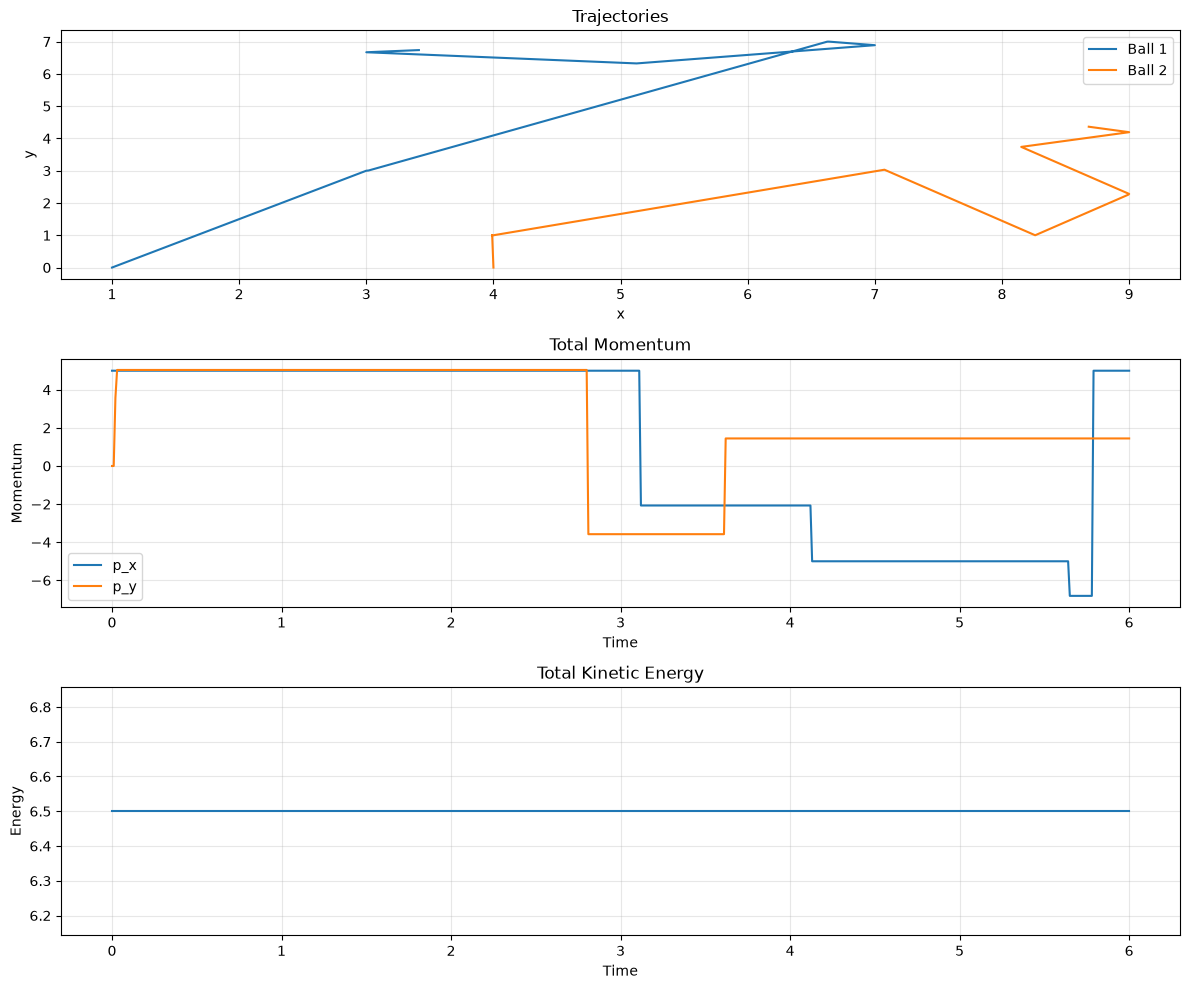

In [295]:
# Part 4
# Plotting the collisions

box = (0 ,10 ,0 ,10)
times, trajectories, momentum, energy = ball_collisions(
    bodies, 600, 0.01,box ,1.0)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(trajectories[:, 0, 0], trajectories[:, 0, 1], label="Ball 1")
axes[0].plot(trajectories[:, 1, 0], trajectories[:, 1, 1], label="Ball 2")
axes[0].set_title("Trajectories")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, momentum[:, 0], label="p_x")
axes[1].plot(times, momentum[:, 1], label="p_y")
axes[1].set_title("Total Momentum")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Momentum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, energy)
axes[2].set_title("Total Kinetic Energy")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Energy")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This graphs show the trajectories, total momentum and total kinetic energies of two colliding balls.

With elastic collisions and elastic walls, what should total KE do over time? Does yours? What about total momentum — and why does bouncing off a wall change it? (Think about what the wall represents.)

KE should stay constant over time. Mine does stay constant. The total momentum soes change because the wall absorbs the momentum.

Part C — Inelastic Collisions & Energy Accounting (40 points)

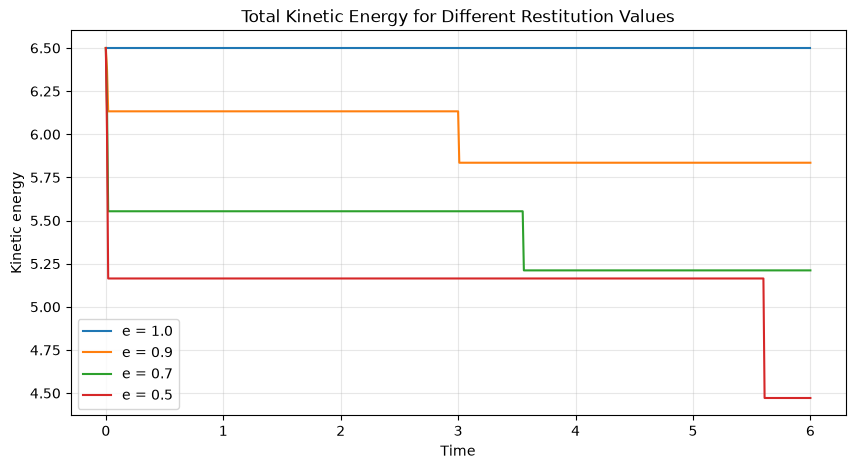

In [296]:
# Part 2
# Running a sweep over e = 1.0, 0.9, 0.7, 0.5 and plotting

e_values = [1.0, 0.9, 0.7, 0.5]
sweep = {}

fig, ax = plt.subplots(figsize=(10, 5))

for e in e_values:
    t, trajectory, p, ke = ball_collisions(
        bodies, steps=600, dt=0.01, box=box, e=e
    )
    sweep[e] = (t, trajectory, p, ke)
    ax.plot(t, ke, label=f"e = {e}")

ax.set_title("Total Kinetic Energy for Different Restitution Values")
ax.set_xlabel("Time")
ax.set_ylabel("Kinetic energy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

This graph shows Kinetic energy as a function of time with different e values.

In [297]:
# Part 3
# Kinetic energy lost in the first collision

m1, m2 = bodies[0]["m"], bodies[1]["m"]
v1 = bodies[0]["v"][0]
v2 = bodies[1]["v"][0]
reduced_mass = m1 * m2 / (m1 + m2)
relative_speed = abs(v1 - v2)
initial_ke = 0.5 * m1 * np.dot(bodies[0]["v"], bodies[0]["v"]) + \
             0.5 * m2 * np.dot(bodies[1]["v"], bodies[1]["v"])

for e in e_values:
    ke = sweep[e][3]

    changes = np.where(np.diff(ke) < -1e-10)[0]
    if len(changes) == 0:
        numerical_loss = 0.0
    else:
        collision_index = changes[0]
        numerical_loss = (ke[collision_index] - ke[collision_index + 1]) / ke[collision_index]

    theoretical_loss = (0.5 * reduced_mass * relative_speed**2 * (1 - e**2)) / initial_ke

    print(f"e value: {e:.1f} | Numerical: {numerical_loss:.4f} | Theoretical: {theoretical_loss:.4f}")

e value: 1.0 | Numerical: 0.0000 | Theoretical: 0.0000
e value: 0.9 | Numerical: 0.0194 | Theoretical: 0.0987
e value: 0.7 | Numerical: 0.0521 | Theoretical: 0.2648
e value: 0.5 | Numerical: 0.0766 | Theoretical: 0.3894


Numerical and Theoretical Energy Lost for e = 1, 0.9, 0.7, and 0.5 collisions

|| Numerical | Theoretical |
|--------| -------- | -------- |
|e = 1|0.0000|0.0000|
|e = 0.9|0.0194|0.0987|
|e = 0.7|0.0521|0.2648|
|e = 0.5|0.0766|0.3894|

In [298]:
def no_wall_ball_collision(bodies, steps, dt, e=1.0):
    """Simulate two balls in open space without boundary walls."""
    b1, b2 = bodies

    m1, m2 = b1["m"], b2["m"]
    R1, R2 = b1["radius"], b2["radius"]

    r1 = np.array(b1["r"], dtype=float, copy=True)
    r2 = np.array(b2["r"], dtype=float, copy=True)
    v1 = np.array(b1["v"], dtype=float, copy=True)
    v2 = np.array(b2["v"], dtype=float, copy=True)

    times = np.arange(steps + 1) * dt
    trajectories = np.empty((steps + 1, 2, 2))
    momentum = np.empty((steps + 1, 2))
    energy = np.empty(steps + 1)

    def record(i):
        trajectories[i] = [r1, r2]
        momentum[i] = m1 * v1 + m2 * v2
        energy[i] = (
            0.5 * m1 * np.dot(v1, v1)
            + 0.5 * m2 * np.dot(v2, v2)
        )

    record(0)

    for i in range(1, steps + 1):
        r1 += v1 * dt
        r2 += v2 * dt

        approaching = np.dot(v2 - v1, r2 - r1) < 0

        if overlapping(r1, r2, R1, R2) and approaching:
            v1, v2 = collide_2d(m1, m2, r1, r2, v1, v2, e)

        record(i)

    return times, trajectories, momentum, energy

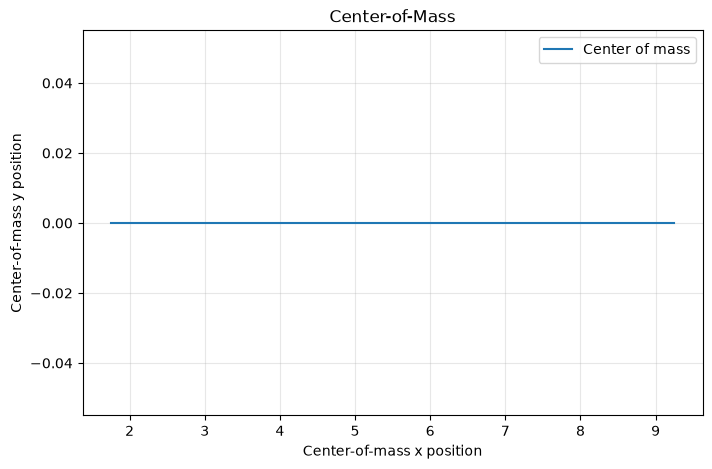

In [299]:
# Part 4
# Plotting center of mass

time, trajectories, momentum, energy = no_wall_ball_collision(bodies, steps=600, dt=0.01, e=1.0)

position = (
    bodies[0]["m"] * trajectories[:, 0, :]
    + bodies[1]["m"] * trajectories[:, 1, :]
) / (bodies[0]["m"] + bodies[1]["m"])

plt.figure(figsize=(8, 5))
plt.plot(position[:, 0], position[:, 1], label="Center of mass")
plt.xlabel("Center-of-mass x position")
plt.ylabel("Center-of-mass y position")
plt.title("Center-of-Mass")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This graph shows the center of mass in the y direction plotted against the x direction.

It should move in a straight line at constant velocity. Explain why this is a powerful correctness check.

It is a powerful correctness check because it was changing it would show that ball arent moving as they should.

Write a short analysis (a few sentences): For e < 1, does total KE ever increase at any step? What would it mean about your code if it did? Why is "KE never increases" a valid test even without an exact solution?

Ke never increases at any step for an e that is less than 1. It would mean that KE is being add to the system. It is a valid test because you should never gain KE if no force is acting on an object.